In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, add
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [2]:
with open("../artifacts/features.pkl", "rb") as f:
    features = pickle.load(f)
with open("../artifacts/mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
with open("../artifacts/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [3]:
all_captions = [c for caps in mapping.values() for c in caps]
vocab_size = len(tokenizer.word_index) + 1

In [4]:
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

In [5]:
print(f"vocab_size : {vocab_size}")
print(f"max_length : {max_length}")

vocab_size : 8781
max_length : 37


In [6]:
image_ids = list(mapping.keys())

In [7]:
train_ids, test_ids = train_test_split(image_ids, test_size=0.1, random_state=42)

In [8]:
print(len(train_ids), len(test_ids))

7281 810


In [9]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []
    n = 0
    while True:
        for key in data_keys:
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq = pad_sequences([seq[:i]], maxlen=max_length)[0]
                    out_seq = to_categorical([seq[i]], num_classes=vocab_size)[0]
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            n += 1
            if n == batch_size:
                yield {"image": np.array(X1), "text": np.array(X2)}, np.array(y)
                X1, X2, y = [], [], []
                n = 0

In [21]:
inputs1 = Input(shape=(4096,), name="image")
fe1 = Dropout(0.3)(inputs1)
fe2 = Dense(256, activation="relu")(fe1)

inputs2 = Input(shape=(max_length,), name="text")
se1 = Embedding(vocab_size, 256)(inputs2)
se2 = Dropout(0.3)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation="relu")(decoder1)
outputs = Dense(vocab_size, activation="softmax")(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer="adam")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 37)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 4096)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 37, 256)   │  2,247,936 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4096)      │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 37, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │  1,048,832 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8781)      │  2,256,717 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,144,589 (23.44 MB)

 Trainable params: 6,144,589 (23.44 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# steps_per_epoch : Number of batches needed to process all training images once
# suppoe total images = 8000, batch_size = 32
# steps_per_epoch = 8000 // 32 = 250
# 1 Epoch

#  = 250 batches

#  = all 8000 images seen once


In [23]:
epochs = 5
batch_size = 32

In [24]:
steps_per_epoch = len(train_ids) // batch_size

In [25]:
steps_per_epoch

227

In [26]:
train_generator = data_generator(train_ids, mapping, features, tokenizer, max_length, vocab_size, batch_size)

In [27]:
history = model.fit(train_generator, epochs=epochs, steps_per_epoch=steps_per_epoch, verbose=1)

Epoch 1/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - loss: 5.3292
Epoch 2/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - loss: 3.5532
Epoch 3/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - loss: 3.1303
Epoch 4/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - loss: 2.8724
Epoch 5/5
227/227 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - loss: 2.6896


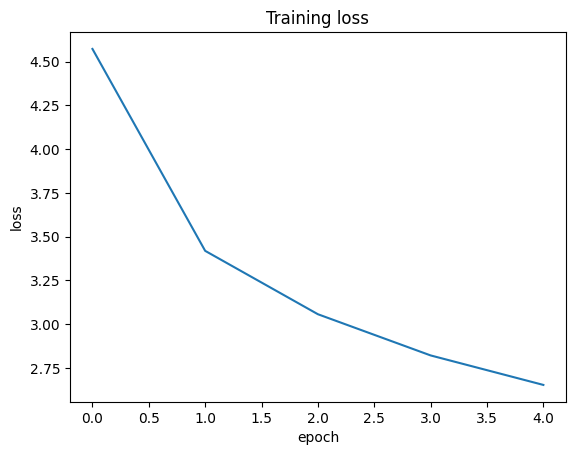

In [28]:
plt.plot(history.history["loss"])
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [29]:
model.save("../artifacts/model.h5")

In [30]:
with open("../artifacts/history.pkl", "wb") as f:
    pickle.dump(history.history, f)